## Visualization of Plant Connectivity

In [15]:
import os
import sys
import numpy as np
# load files for each season
import pickle
import pandas as pd
sys.path.append('../scripts')
from utils import average_across_days

# Choose Ecosystem and Metric
ecosystem = 'LaurentianMapleGrove'  # 'GulfStLawrence', 'LaurentianMapleGrove'
metric = 'transfer_entropy'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

if ecosystem == 'GulfStLawrence':
    from GulfStLawrence_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names_fr
else:
    from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names_fr

df_all_seasons = []
for SEASON in [SPRING, SUMMER, FALL, WINTER]:
    try:
        with open(f'../plant_data_{ecosystem}/{seasons[SEASON]}/connectivity_results_{metric}.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            df_combined, df_avg = average_across_days(dfs_results, metric=metric)
            df_avg["Season"] = SEASON
            df_all_seasons.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for season {seasons[SEASON]}. Skipping...")
        continue

# Sum transfer entropy at each epoch for each season
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)

# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24

if "Season_mapped" not in df_all_seasons_combined.columns:
    df_all_seasons_combined["Season_mapped"] = df_all_seasons_combined["Season"].map(seasons)


season_colors = {
    human_name: color
    for (_, human_name), color in zip(seasons.items(),
                                      ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])
}
plant_names = {i: name for i, name in enumerate(plant_common_names_fr.values())}

In [111]:
season_colors

{'Spring 2024': '#2ca02c',
 'Summer 2024': '#ffcc00',
 'Fall 2024': '#ff7f0e',
 'Winter 2025': '#1f77b4'}

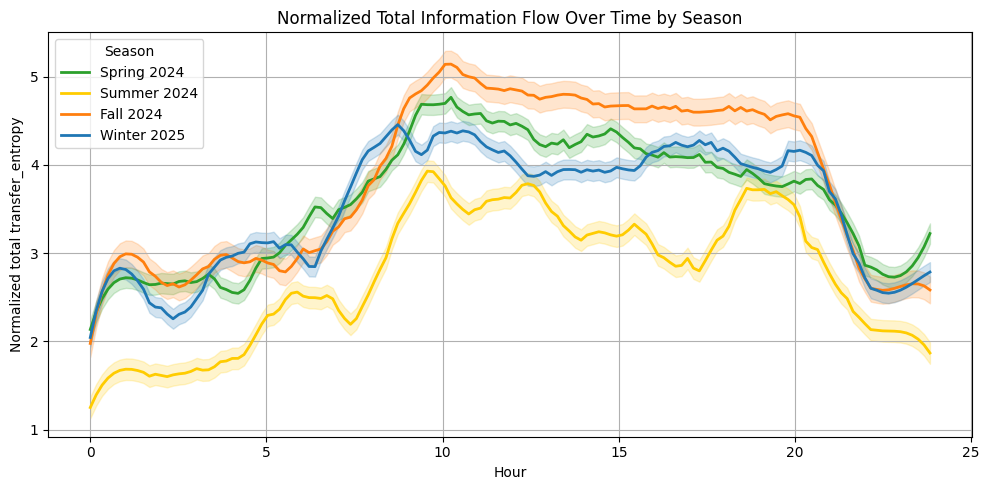

In [76]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1) Ensure Hour column exists
total_epochs = df_all_seasons_combined["Epoch"].max() + 1
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24

# 2) Compute N_max = P*(P-1)
plants = np.union1d(df_all_seasons_combined["Plant1"].unique(),
                    df_all_seasons_combined["Plant2"].unique())
N_max = len(plants) * (len(plants) - 1)

# 3) Extract and sort season names
season_names = list(seasons.values())
season_index = {"Winter":0, "Spring":1, "Summer":2, "Fall":3}
season_order = sorted(
    season_names,
    key=lambda nm: (int(nm.split()[1]), season_index[nm.split()[0]])
)

# 4) Assign your custom colors in that order
colors = ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4", ]
color_map = dict(zip(season_order, colors))

# 5) Plot normalized total TE over the day
plt.figure(figsize=(10, 5))
for season in season_order:
    sub = df_all_seasons_combined[df_all_seasons_combined["Season_mapped"] == season]
    sum_te   = sub.groupby("Epoch")[metric].sum()
    count_te = sub.groupby("Epoch")[metric].count()
    normalized_te = (sum_te / count_te) * N_max
    smoothed = savgol_filter(normalized_te.values, window_length=20, polyorder=3)
    ci    = 1.96 * np.std(smoothed) / np.sqrt(len(smoothed))
    lower = smoothed - ci
    upper = smoothed + ci
    hours = normalized_te.index / total_epochs * 24

    plt.plot(hours, smoothed,
             color=color_map[season],
             linewidth=2,
             label=season)
    plt.fill_between(hours, lower, upper,
                     color=color_map[season],
                     alpha=0.2)

plt.xlabel("Hour")
plt.ylabel(f"Normalized total {metric}")
plt.title("Normalized Total Information Flow Over Time by Season")
plt.legend(title="Season")
plt.grid(True)
plt.tight_layout()
plt.show()


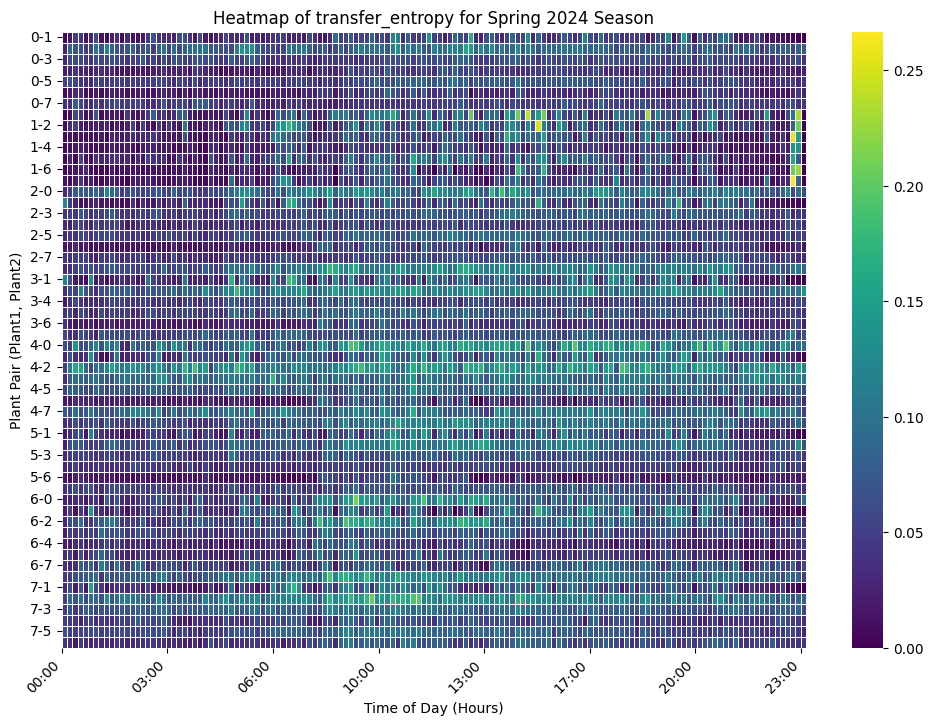

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the season to plot
season = SPRING

# Reset index to convert MultiIndex into columns for easier plotting
df_plot = df_avg.reset_index()
# select one season
df_plot = df_plot[df_plot['Season'] == season]

# Get the total number of epochs
total_epochs = df_plot["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24  # Convert epochs to hours

# Pivot table for heatmap
pivot_table = df_plot.pivot(index=["Plant1", "Plant2"], columns="Hour", values=metric)

# Define color scale range
y_min = 0
y_max = np.max(pivot_table.values)  # Set max value for color scale

# Create heatmap with better spacing
plt.figure(figsize=(12, 8))
ax = sns.heatmap(pivot_table, cmap="viridis", annot=False, linewidths=0.5, vmin=y_min, vmax=y_max)

# Format x-axis labels to properly span the full range
plt.xlabel("Time of Day (Hours)")
plt.ylabel("Plant Pair (Plant1, Plant2)")
plt.title(f"Heatmap of {metric} for {seasons[season]} Season")

# **Fix time labels across 142 epochs**  
num_ticks = 8  # Set a reasonable number of labels (adjust if needed)
time_ticks = np.linspace(0, total_epochs - 1, num_ticks)  # Spread labels evenly
time_labels = [f"{int(hour):02d}:00" for hour in (time_ticks / total_epochs * 24)]  # Convert back to hours

# Apply new time labels
plt.xticks(ticks=time_ticks, labels=time_labels, rotation=45, ha="right")

# Show plot
plt.show()


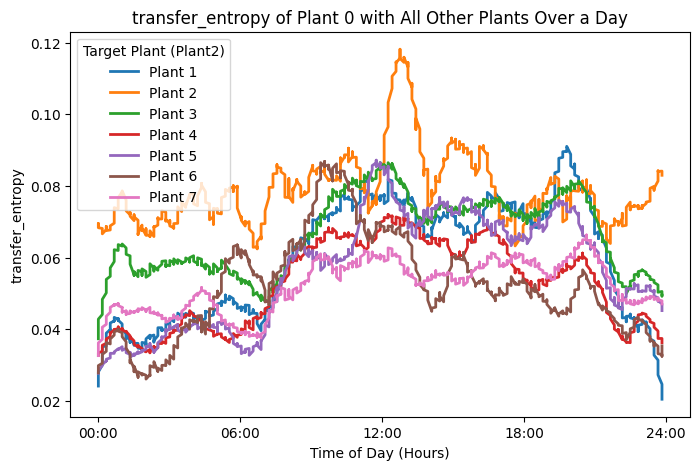

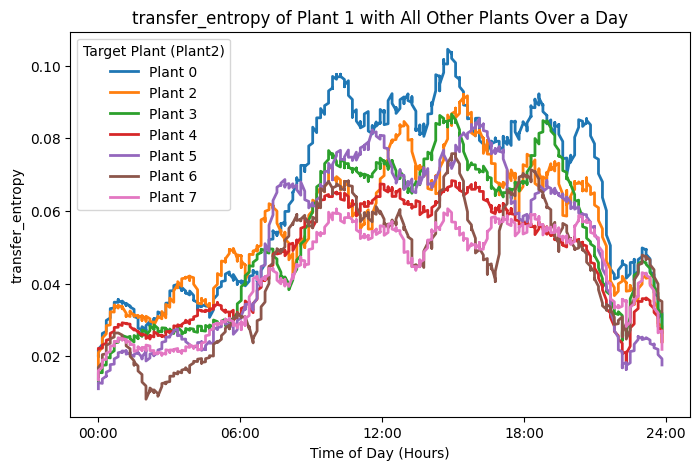

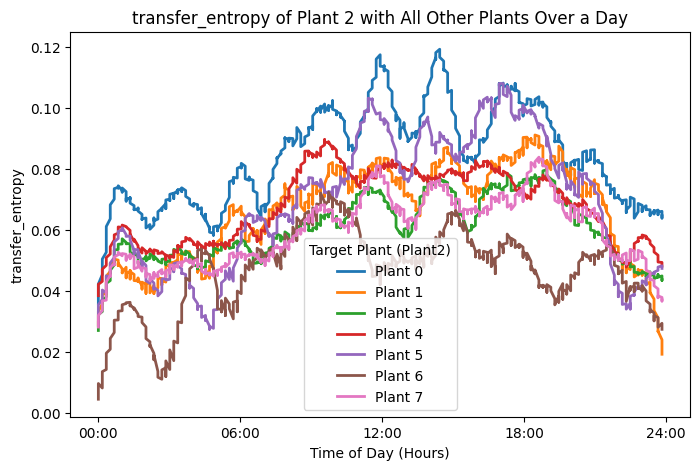

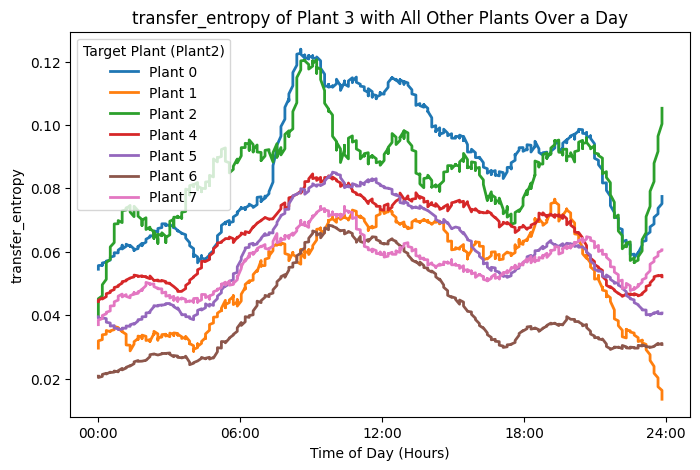

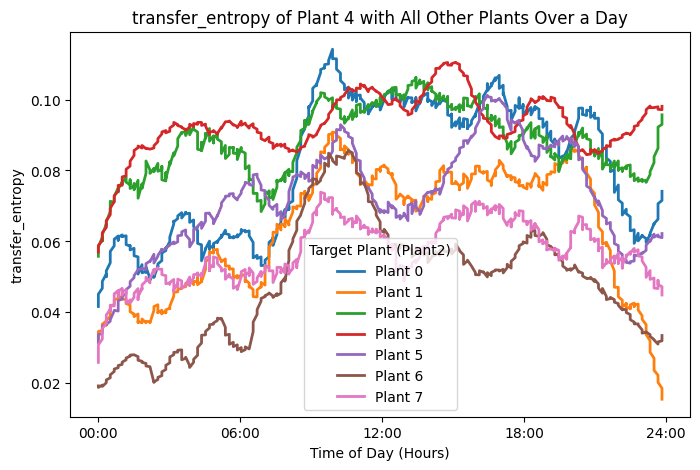

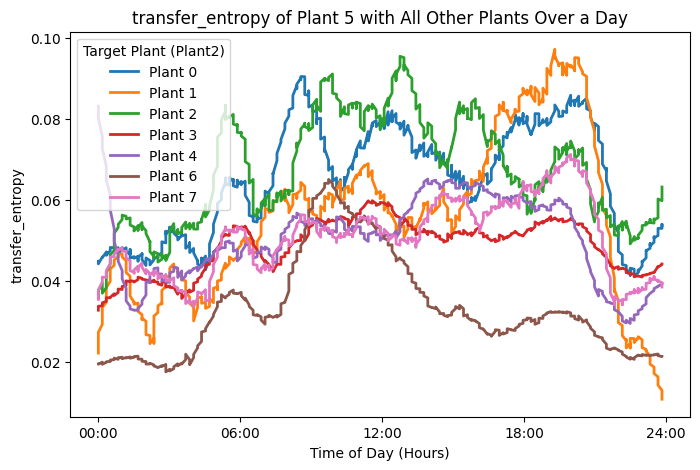

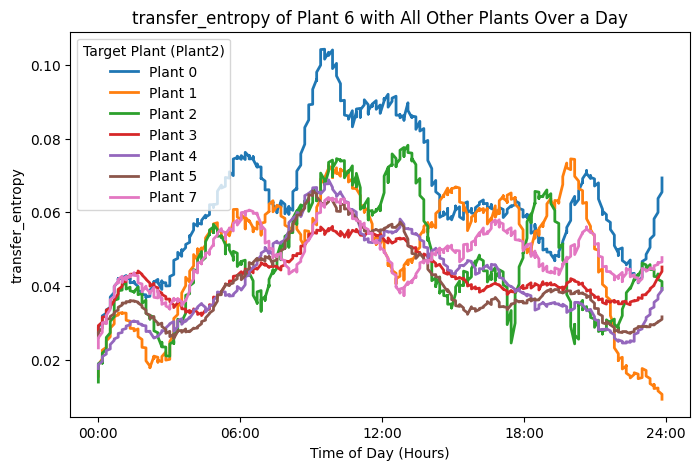

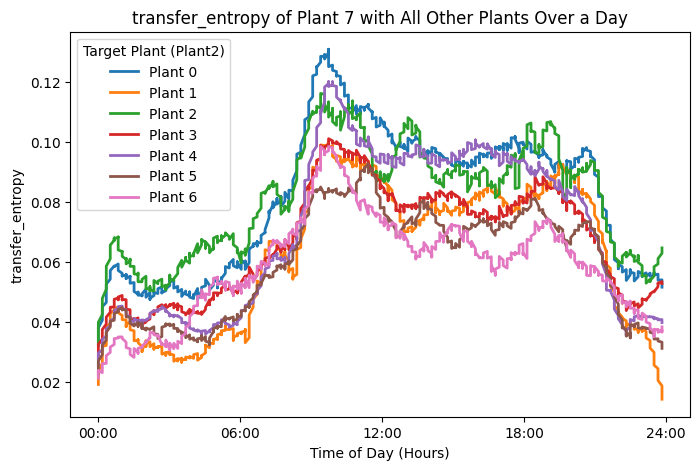

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter  # Import Savitzky-Golay filter

# Reset index to convert MultiIndex into columns for easier plotting
df_plot = df_avg.reset_index()

# Convert "Epoch" to hours of the day (assuming epochs are evenly spaced over 24 hours)
total_epochs = df_plot["Epoch"].max() + 1  # Number of epochs in a full day
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24  # Scale to hours (0-24)

# Set smoothing parameters (adjust these for desired smoothness)
window_length = 50  # Must be an odd number (increase for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants
plants = df_plot["Plant1"].unique()

# Generate one plot per plant
for plant in plants:
    plt.figure(figsize=(8, 5))  # Create a new figure for each plant
    
    # Subset data for the specific plant
    subset = df_plot[df_plot["Plant1"] == plant]
    
    # Apply smoothing for each "Plant2" separately
    for plant2 in subset["Plant2"].unique():
        subset_p2 = subset[subset["Plant2"] == plant2].sort_values(by="Hour")  # Sort by time
        
        # Apply Savitzky-Golay filter for smoothness
        smoothed_entropy = savgol_filter(subset_p2[metric], window_length, polyorder, mode="nearest")
        
        # Plot smoothed data
        plt.plot(subset_p2["Hour"], smoothed_entropy, label=f"Plant {plant2}", linewidth=2)

    # Set labels and title
    plt.xlabel("Time of Day (Hours)")
    plt.ylabel(metric)
    plt.title(f"{metric} of Plant {plant} with All Other Plants Over a Day")
    
    # Customize x-axis ticks to show specific times (e.g., 0, 6, 12, 18, 24)
    plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])
    
    # Add legend
    plt.legend(title="Target Plant (Plant2)")

    # Show the plot for each plant
    plt.show()


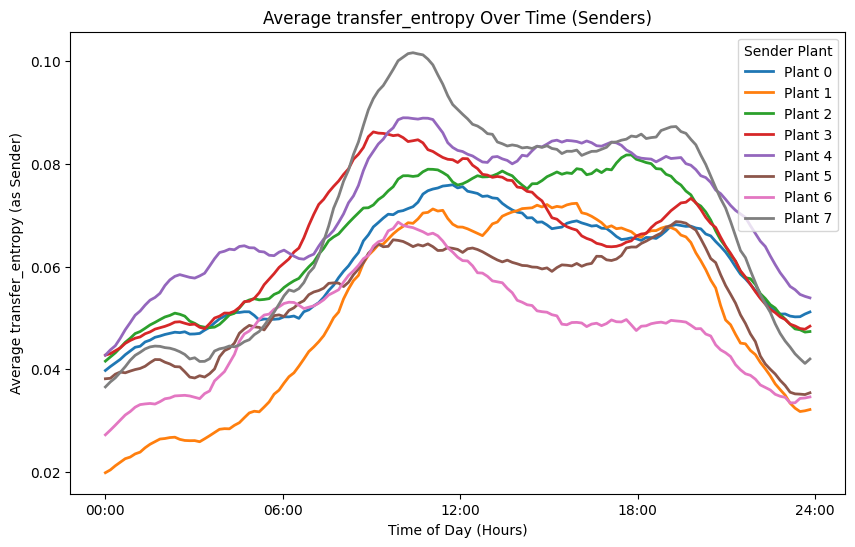

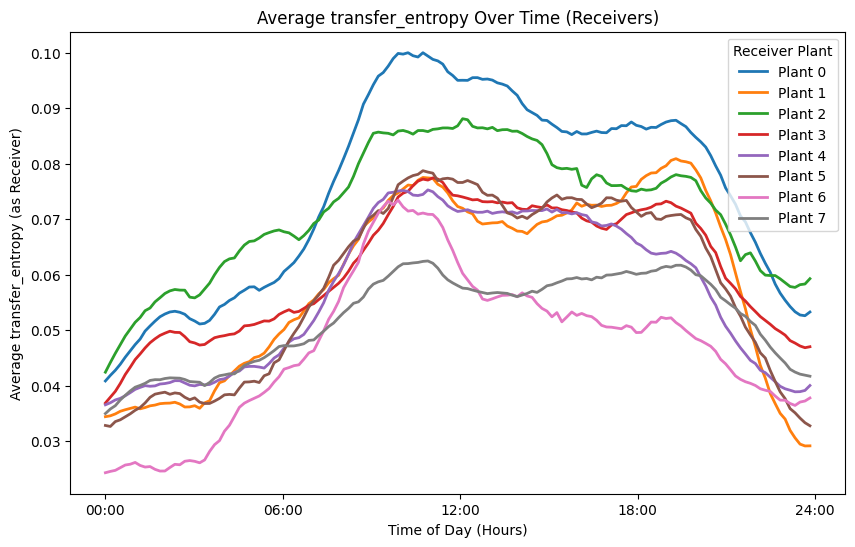

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter  # Import Savitzky-Golay filter

# Reset index to convert MultiIndex into columns for easier plotting
df_plot = df_avg.reset_index()

# Convert "Epoch" to hours of the day (assuming epochs are evenly spaced over 24 hours)
total_epochs = df_plot["Epoch"].max() + 1  # Number of epochs in a full day
df_plot["Hour"] = df_plot["Epoch"] / total_epochs * 24  # Scale to hours (0-24)

# Compute average transfer entropy per sender (Plant1) and per receiver (Plant2)
df_senders = df_plot.groupby(["Epoch", "Plant1"], as_index=False)[metric].mean()
df_receivers = df_plot.groupby(["Epoch", "Plant2"], as_index=False)[metric].mean()

# Rename columns for clarity
df_senders.rename(columns={"Plant1": "Plant"}, inplace=True)
df_receivers.rename(columns={"Plant2": "Plant"}, inplace=True)

# Convert "Epoch" to "Hour"
df_senders["Hour"] = df_senders["Epoch"] / total_epochs * 24
df_receivers["Hour"] = df_receivers["Epoch"] / total_epochs * 24

# Set smoothing parameters (adjust these for desired smoothness)
window_length = 33  # Must be an odd number (increase for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants
plants = sorted(df_plot["Plant1"].unique())  # Ensure consistent order

# Create **one plot for senders**
plt.figure(figsize=(10, 6))
for plant in plants:
    subset = df_senders[df_senders["Plant"] == plant].sort_values(by="Hour")
    if len(subset) >= window_length:  # Ensure enough points for smoothing
        smoothed_entropy = savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
        # use runnig average
        # smoothed_entropy = subset["Transfer Entropy"].rolling(window=window_length, min_periods=1).mean()
    else:
        smoothed_entropy = subset[metric].values  # Use raw values if not enough points
    
    plt.plot(subset["Hour"], smoothed_entropy, label=f"Plant {plant}", linewidth=2)

# Format plot
plt.xlabel("Time of Day (Hours)")
plt.ylabel(f"Average {metric} (as Sender)")
plt.title(f"Average {metric} Over Time (Senders)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])
plt.legend(title="Sender Plant", loc="upper right")
plt.show()

# Create **one plot for receivers**
plt.figure(figsize=(10, 6))
for plant in plants:
    subset = df_receivers[df_receivers["Plant"] == plant].sort_values(by="Hour")
    if len(subset) >= window_length:  # Ensure enough points for smoothing
        smoothed_entropy = savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
    else:
        smoothed_entropy = subset[metric].values  # Use raw values if not enough points

    plt.plot(subset["Hour"], smoothed_entropy, label=f"Plant {plant}", linewidth=2)

# Format plot
plt.xlabel("Time of Day (Hours)")
plt.ylabel(f"Average {metric} (as Receiver)")
plt.title(f"Average {metric} Over Time (Receivers)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])
plt.legend(title="Receiver Plant", loc="upper right")
plt.show()


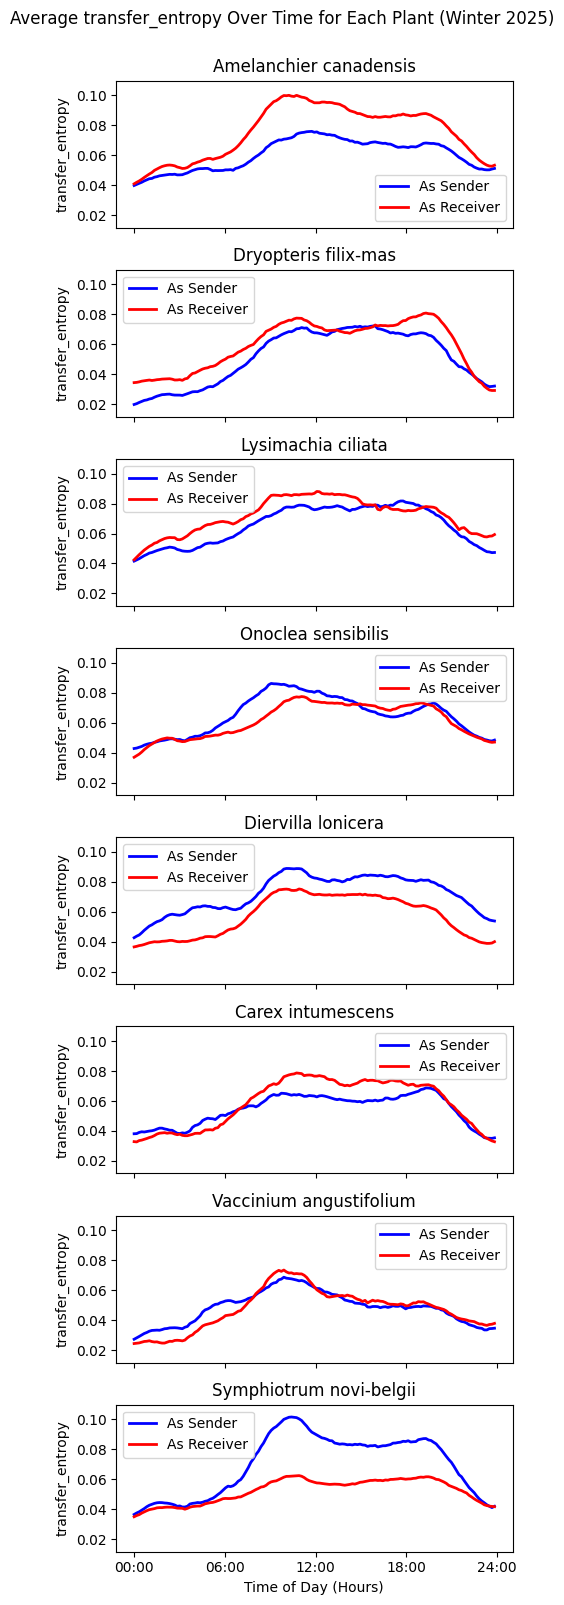

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# Mapping of plant indices to names
plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
# List of plants
plants = sorted(df_senders["Plant"].unique())

# Compute global y-axis limits
y_min = float("inf")
y_max = float("-inf")

for plant in plants:
    for df in [df_senders, df_receivers]:
        subset = df[df["Plant"] == plant].sort_values(by="Hour")
        if len(subset) >= window_length:
            smoothed_entropy = savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
        else:
            smoothed_entropy = subset[metric].values
        y_min = min(y_min, smoothed_entropy.min())
        y_max = max(y_max, smoothed_entropy.max())

# Add padding to y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

# Create subplots
fig, axes = plt.subplots(nrows=len(plants), figsize=(5, len(plants) * 2), sharex=True)

for i, plant in enumerate(plants):
    ax = axes[i]
    
    # Process senders
    subset_senders = df_senders[df_senders["Plant"] == plant].sort_values(by="Hour")
    smoothed_sender = (
        savgol_filter(subset_senders[metric], window_length, polyorder, mode="nearest")
        if len(subset_senders) >= window_length else subset_senders[metric].values
    )
    ax.plot(subset_senders["Hour"], smoothed_sender, label="As Sender", color="blue", linewidth=2)

    # Process receivers
    subset_receivers = df_receivers[df_receivers["Plant"] == plant].sort_values(by="Hour")
    smoothed_receiver = (
        savgol_filter(subset_receivers[metric], window_length, polyorder, mode="nearest")
        if len(subset_receivers) >= window_length else subset_receivers[metric].values
    )
    ax.plot(subset_receivers["Hour"], smoothed_receiver, label="As Receiver", color="red", linewidth=2)

    # Format subplot
    ax.set_ylabel(metric)
    ax.set_title(plant_names[plant])  # Use plant name
    ax.legend()
    ax.set_ylim(y_min, y_max)

# Format x-axis
plt.xlabel("Time of Day (Hours)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])

# Add suptitle with more space
plt.suptitle(f"Average {metric} Over Time for Each Plant (Winter 2025)", y=1.)
plt.tight_layout()
plt.show()


## All seasons

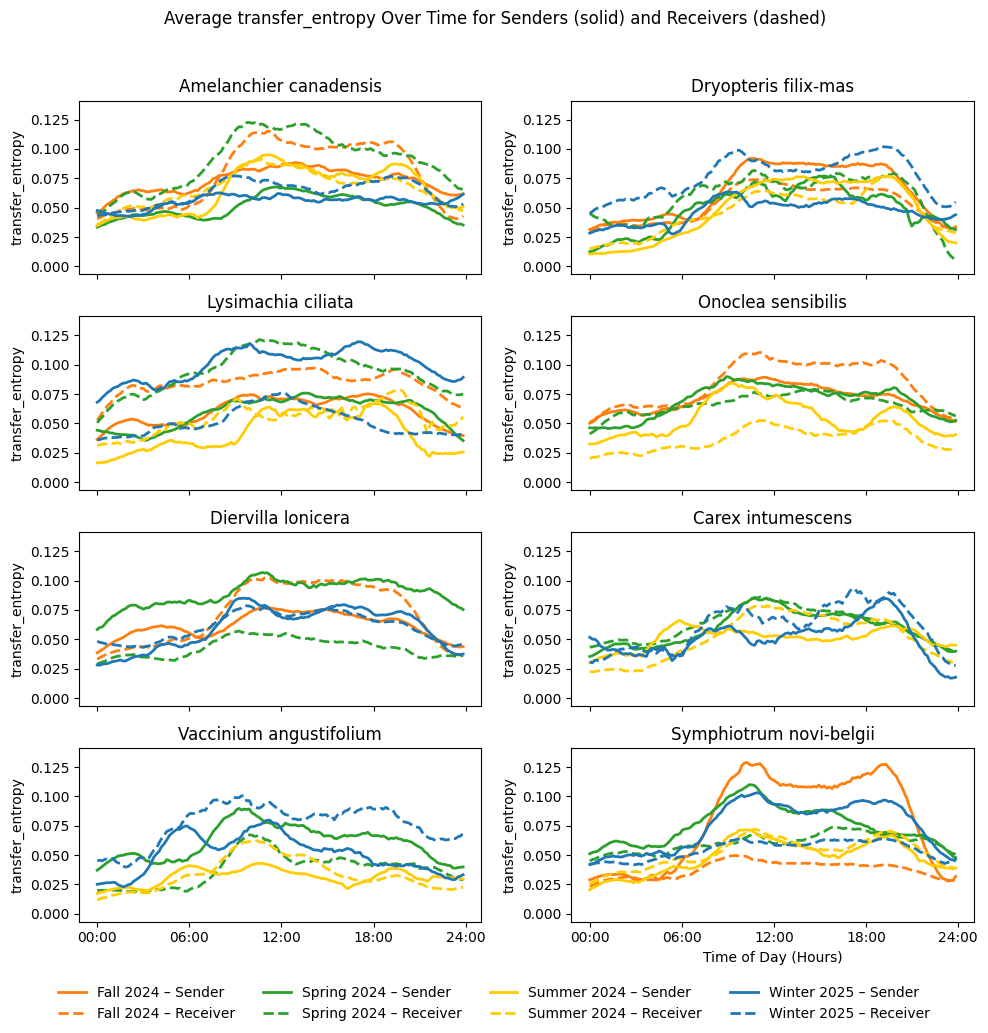

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

# === 1) Build plant_names and season_mapping as before ===
plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
season_mapping = seasons.copy()  # your mapping from code values → human names

# === 2) Create a new mapped column only if it doesn't already exist ===
if "Season_mapped" not in df_all_seasons_combined.columns:
    df_all_seasons_combined["Season_mapped"] = df_all_seasons_combined["Season"].map(season_mapping)

# === 3) Define season colors on the mapped names ===
season_colors = {
    human_name: color
    for (_, human_name), color in zip(season_mapping.items(),
                                      ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])
}

# === smoothing params ===
window_length = 33  # odd
polyorder = 3

# === unique plants & seasons (mapped) ===
plants = sorted(df_all_seasons_combined["Plant1"].unique())
mapped_seasons = sorted(df_all_seasons_combined["Season_mapped"].dropna().unique())

# === compute global y-limits ===
y_min, y_max = np.inf, -np.inf
for season in mapped_seasons:
    df_seas = df_all_seasons_combined[df_all_seasons_combined["Season_mapped"] == season]
    df_senders   = df_seas.groupby(["Hour","Plant1"],   as_index=False)[metric].mean()
    df_receivers = df_seas.groupby(["Hour","Plant2"],   as_index=False)[metric].mean()
    for df_grp in (df_senders, df_receivers):
        for plant in plants:
            col = df_grp.columns[1]  # Plant1 or Plant2
            sub = df_grp[df_grp[col] == plant].sort_values("Hour")
            if sub.empty: continue
            vals = (savgol_filter(sub[metric], window_length, polyorder, mode="nearest")
                    if len(sub) >= window_length else sub[metric].values)
            y_min = min(y_min, vals.min())
            y_max = max(y_max, vals.max())

# add padding
yrange = y_max - y_min
y_min -= 0.1 * yrange
y_max += 0.1 * yrange

# === set up subplots ===
n_cols = 2
n_rows = (len(plants) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 2.5), sharex=True)
axes = axes.flatten()

for idx, plant in enumerate(plants):
    ax = axes[idx]
    for season in mapped_seasons:
        df_seas = df_all_seasons_combined[df_all_seasons_combined["Season_mapped"] == season]
        df_senders   = df_seas.groupby(["Hour","Plant1"],   as_index=False)[metric].mean()
        df_receivers = df_seas.groupby(["Hour","Plant2"],   as_index=False)[metric].mean()
        color = season_colors[season]

        # --- sender (solid) ---
        send = df_senders[df_senders["Plant1"] == plant].sort_values("Hour")
        if not send.empty:
            y_s = (savgol_filter(send[metric], window_length, polyorder, mode="nearest")
                   if len(send) >= window_length else send[metric].values)
            ax.plot(send["Hour"], y_s,
                    label=f"{season} – Sender",
                    color=color, linestyle="-", linewidth=2)

        # --- receiver (dashed) ---
        recv = df_receivers[df_receivers["Plant2"] == plant].sort_values("Hour")
        if not recv.empty:
            y_r = (savgol_filter(recv[metric], window_length, polyorder, mode="nearest")
                   if len(recv) >= window_length else recv[metric].values)
            ax.plot(recv["Hour"], y_r,
                    label=f"{season} – Receiver",
                    color=color, linestyle="--", linewidth=2)

    ax.set_title(plant_names[plant])
    ax.set_ylabel(metric)
    ax.set_ylim(y_min, y_max)

# remove any extra axes
for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

# common x-axis formatting
plt.xlabel("Time of Day (Hours)")
plt.xticks(np.arange(0,25,6), ["00:00","06:00","12:00","18:00","24:00"])

# shared legend
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False)

plt.suptitle(f"Average {metric} Over Time for Senders (solid) and Receivers (dashed)", y=1.02)
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()


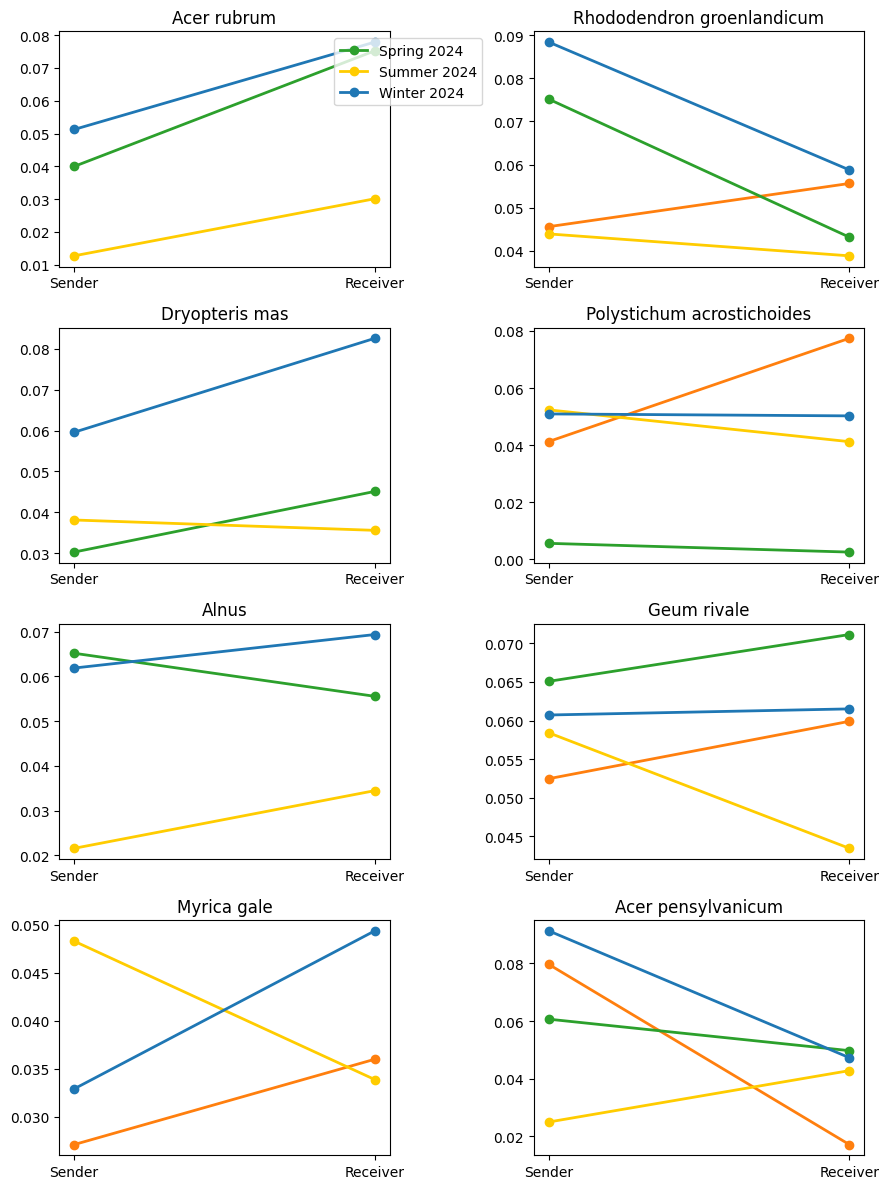

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Cell: Small-multiple slopegraphs of Sender vs Receiver using 'season_colors'
if 'df_all_seasons_combined' not in globals():
    print("Please define df_all_seasons_combined, season_mapping, plant_names, metric, and season_colors before running this cell.")
else:
    # Ensure Season_mapped exists
    if 'Season_mapped' not in df_all_seasons_combined.columns:
        df_all_seasons_combined['Season_mapped'] = df_all_seasons_combined['Season'].map(season_mapping)

    # Compute sender and receiver averages
    sender_avg = (
        df_all_seasons_combined
        .groupby(['Plant1', 'Season_mapped'])[metric]
        .mean()
        .reset_index()
        .rename(columns={'Plant1': 'Plant', metric: 'sender_avg', 'Season_mapped': 'Season'})
    )
    receiver_avg = (
        df_all_seasons_combined
        .groupby(['Plant2', 'Season_mapped'])[metric]
        .mean()
        .reset_index()
        .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg', 'Season_mapped': 'Season'})
    )

    # Merge into single DataFrame
    avg_df = pd.merge(sender_avg, receiver_avg, on=['Plant', 'Season'], how='inner')

    # Unique plants and seasons
    plants = sorted(avg_df['Plant'].unique())
    seasons = sorted(avg_df['Season'].unique())

    # Subplot grid
    n_cols = 2
    n_rows = (len(plants) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, n_rows * 3))
    axes = axes.flatten()

    for idx, plant in enumerate(plants):
        ax = axes[idx]
        sub = avg_df[avg_df['Plant'] == plant]
        for season in seasons:
            row = sub[sub['Season'] == season]
            if row.empty:
                continue
            s = row['sender_avg'].values[0]
            r = row['receiver_avg'].values[0]
            color = season_colors.get(season, 'gray')
            ax.plot([0, 1], [s, r],
                    marker='o',
                    color=color,
                    linewidth=2,
                    label=season)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Sender', 'Receiver'])
        ax.set_title(plant_names.get(plant, plant))
        if idx == 0:
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    # Remove any empty subplots
    for j in range(len(plants), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


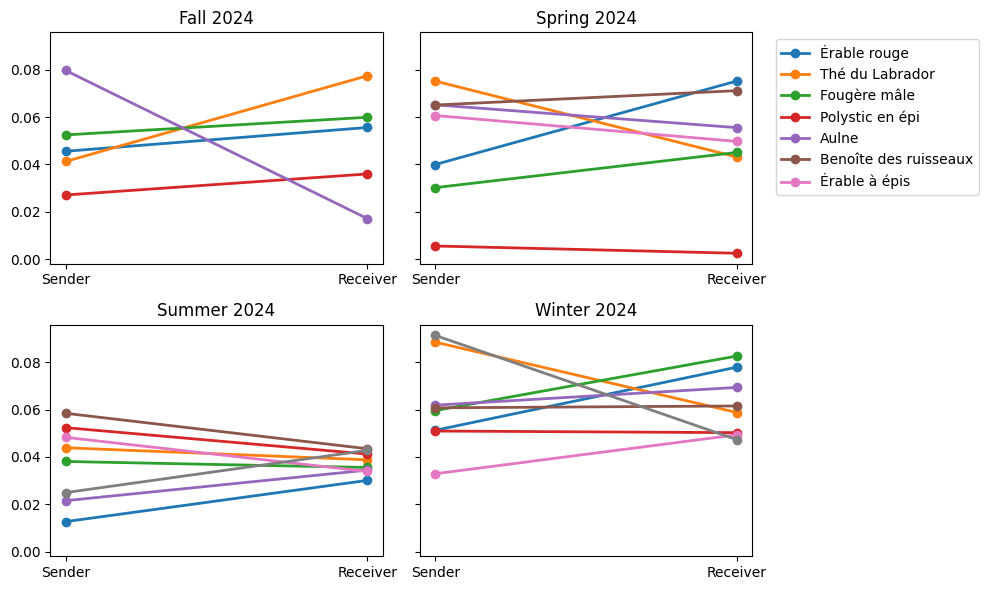

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure Season_mapped exists
df = df_all_seasons_combined.copy()
if 'Season_mapped' not in df.columns:
    df['Season_mapped'] = df['Season'].map(season_mapping)

# Compute sender and receiver averages per plant per season
sender_avg = (
    df.groupby(['Plant1', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1': 'Plant', metric: 'sender_avg', 'Season_mapped': 'Season'})
)
receiver_avg = (
    df.groupby(['Plant2', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg', 'Season_mapped': 'Season'})
)

# Merge into single DataFrame
avg_df = pd.merge(sender_avg, receiver_avg, on=['Plant', 'Season'], how='inner')

# Unique seasons and plants
seasons = sorted(avg_df['Season'].unique())
plants = sorted(avg_df['Plant'].unique())

# Plot one subplot per season
n_cols = 2
n_rows = (len(seasons) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 3), sharey=True)
axes = axes.flatten()

for idx, season in enumerate(seasons):
    ax = axes[idx]
    sub = avg_df[avg_df['Season'] == season]

    for plant in plants:
        row = sub[sub['Plant'] == plant]
        if row.empty:
            continue
        s = row['sender_avg'].values[0]
        r = row['receiver_avg'].values[0]
        ax.plot([0, 1], [s, r],
                marker='o',
                linewidth=2,
                label=plant_names.get(plant, plant))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Sender', 'Receiver'])
    ax.set_title(season)
    if idx == 1:
        ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

# Remove any empty subplots
for j in range(len(seasons), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


{0: 'Amelanchier canadensis',
 1: 'Dryopteris filix-mas',
 2: 'Lysimachia ciliata',
 3: 'Onoclea sensibilis',
 4: 'Diervilla lonicera',
 5: 'Carex intumescens',
 6: 'Vaccinium angustifolium',
 7: 'Symphiotrum novi-belgii'}

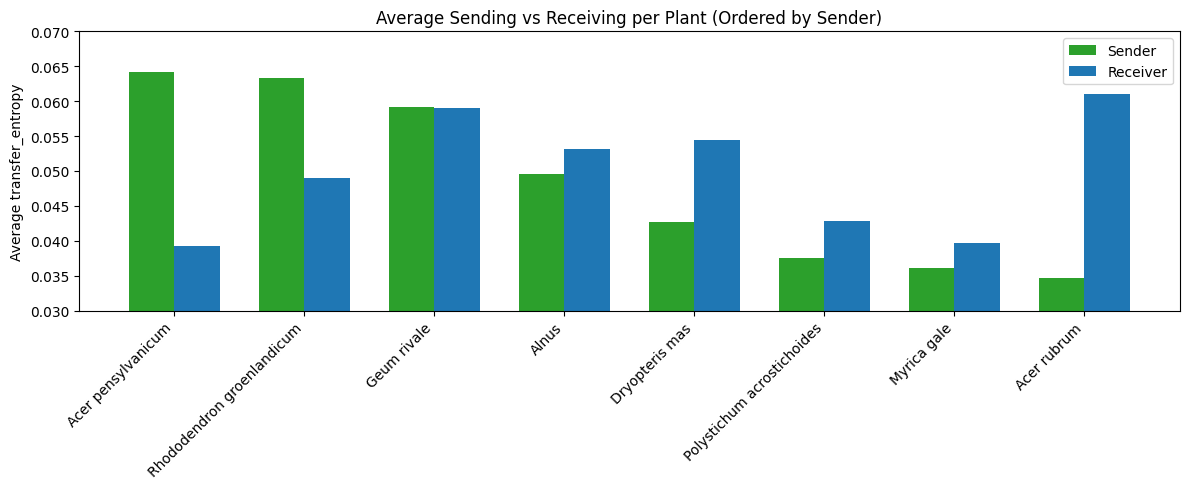

In [123]:
import numpy as np
import matplotlib.pyplot as plt
plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
# Ensure Season_mapped exists
if 'Season_mapped' not in df_all_seasons_combined.columns:
    df_all_seasons_combined['Season_mapped'] = df_all_seasons_combined['Season'].map(season_mapping)

# 1) Compute per-plant, per-season sender means
sender_df = (
    df_all_seasons_combined
    .groupby(['Plant1', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant1': 'Plant', metric: 'sender_avg'})
)

# 2) Compute per-plant, per-season receiver means
receiver_df = (
    df_all_seasons_combined
    .groupby(['Plant2', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg'})
)

# 3) Average across seasons for each plant
sender_mean = sender_df.groupby('Plant')['sender_avg'].mean()
receiver_mean = receiver_df.groupby('Plant')['receiver_avg'].mean()

# 4) Order plants by descending sender mean
ordered_plants = sender_mean.sort_values(ascending=False).index.tolist()

# 5) Prepare x positions
x = np.arange(len(ordered_plants))
width = 0.35

# 6) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2,
       [sender_mean[p] for p in ordered_plants],
       width, label='Sender', color='#2ca02c')
ax.bar(x + width/2,
       [receiver_mean.get(p, np.nan) for p in ordered_plants],
       width, label='Receiver', color='#1f77b4')

# 7) Formatting
ax.set_xticks(x)
ax.set_xticklabels([plant_names.get(p, p) for p in ordered_plants], rotation=45, ha='right')
ax.set_ylabel(f'Average {metric}')
ax.set_title('Average Sending vs Receiving per Plant (Ordered by Sender)')
ax.set_ylim(0.03, 0.07)
ax.legend()
plt.tight_layout()
plt.show()


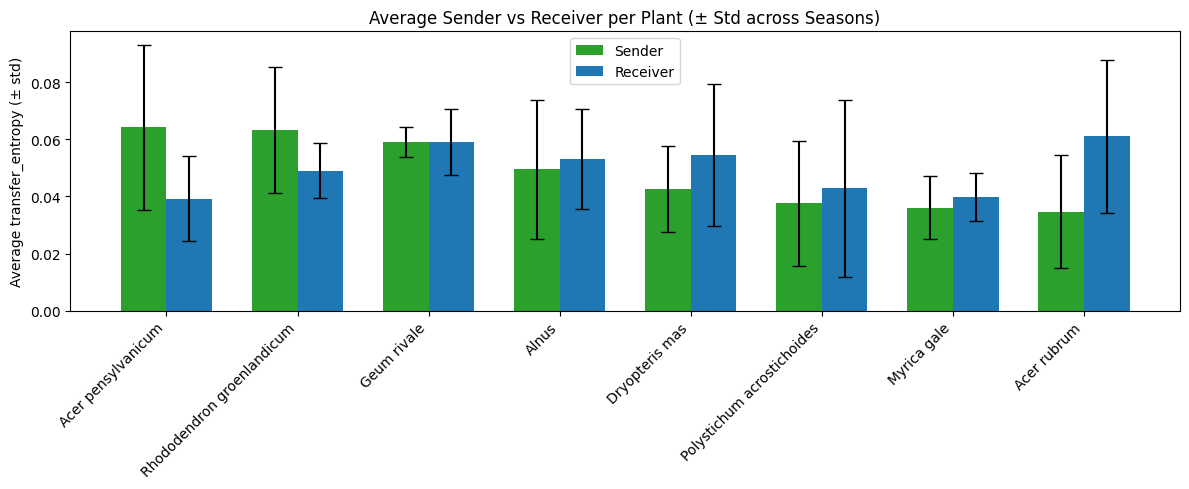

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Prepare DataFrame and ensure Season_mapped
df = df_all_seasons_combined.copy()
if 'Season_mapped' not in df.columns:
    df['Season_mapped'] = df['Season'].map(season_mapping)

# 2) Compute per-plant, per-season sender and receiver means
sender_df = (
    df.groupby(['Plant1','Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1':'Plant', metric:'Value'})
)
sender_df['Type'] = 'Sender'

receiver_df = (
    df.groupby(['Plant2','Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2':'Plant', metric:'Value'})
)
receiver_df['Type'] = 'Receiver'

combined = pd.concat([sender_df, receiver_df], ignore_index=True)

# 3) Compute statistics per Plant and Type across seasons
stats = (
    combined
    .groupby(['Plant','Type'])['Value']
    .agg(['mean','std'])
    .reset_index()
)

# 4) Order plants by descending sender mean
order = stats[stats['Type']=='Sender'].sort_values('mean', ascending=False)['Plant'].tolist()

# 5) Bar plot with error bars
x = np.arange(len(order))
width = 0.35
color_map = {'Sender':'#2ca02c','Receiver':'#1f77b4'}

fig, ax = plt.subplots(figsize=(12, 5))
for typ in ['Sender','Receiver']:
    subset = stats[stats['Type']==typ].set_index('Plant').loc[order]
    ax.bar(x + (-width/2 if typ=='Sender' else width/2),
           subset['mean'],
           width,
           yerr=subset['std'],
           capsize=5,
           label=typ,
           color=color_map[typ]
    )

ax.set_xticks(x)
ax.set_xticklabels([plant_names.get(p, p) for p in order], rotation=45, ha='right')
ax.set_ylabel(f'Average {metric} (± std)')
ax.set_title('Average Sender vs Receiver per Plant (± Std across Seasons)')
ax.legend()
plt.tight_layout()
plt.show()


{4: 8.657865820417542e-45, 7: 1.1757144831036742e-28, 2: 1.519366771216561e-08, 3: 3.493769811965581e-05, 0: 6.906035462516576e-36, 5: 4.8605802549782496e-05, 1: 1.5629966955082704e-13, 6: 0.19022964164850387}


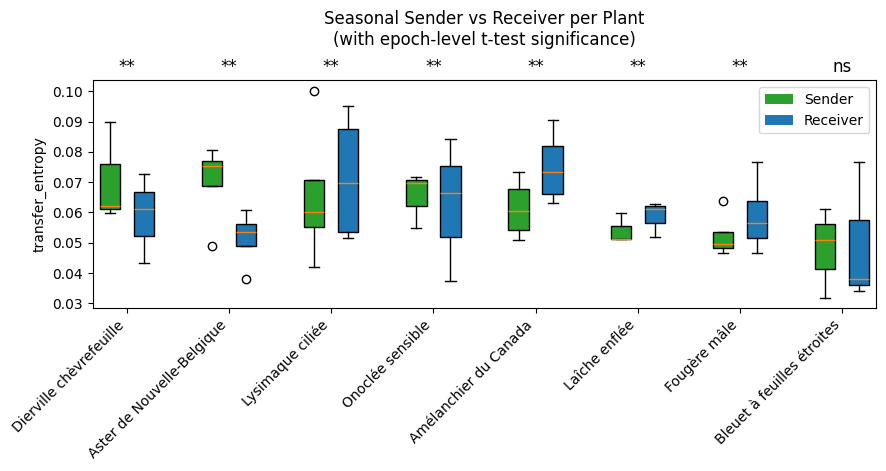

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from matplotlib.patches import Patch

# Copy DataFrame and ensure Season_mapped exists
df = df_all_seasons_combined.copy()
if 'Season_mapped' not in df.columns:
    df['Season_mapped'] = df['Season'].map(season_mapping)

# 1) Compute per-plant, per-epoch values for sender and receiver
sender_epoch = (
    df.groupby(['Plant1', 'Epoch'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1':'Plant', metric:'sender'})
)
receiver_epoch = (
    df.groupby(['Plant2', 'Epoch'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2':'Plant', metric:'receiver'})
)

# Merge sender & receiver so they align by Plant & Epoch
paired_epoch = pd.merge(sender_epoch, receiver_epoch, on=['Plant','Epoch'], how='inner')

# 2) Compute per-plant, per-season means for the boxplot
sender_df = (
    df.groupby(['Plant1', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant1':'Plant', metric:'Value'})
)
sender_df['Type'] = 'Sender'
receiver_df = (
    df.groupby(['Plant2', 'Season_mapped'])[metric]
      .mean()
      .reset_index()
      .rename(columns={'Plant2':'Plant', metric:'Value'})
)
receiver_df['Type'] = 'Receiver'
combined = pd.concat([sender_df, receiver_df], ignore_index=True)

# 3) Determine ordering by descending mean sender (seasonal)
order = sender_df.groupby('Plant')['Value'].mean().sort_values(ascending=False).index.tolist()

# 4) Run paired t-test per plant using all epochs
p_values = {}
for plant in order:
    s_vals = paired_epoch[paired_epoch['Plant']==plant]['sender']
    r_vals = paired_epoch[paired_epoch['Plant']==plant]['receiver']
    if len(s_vals) >= 2 and len(r_vals) >= 2:
        _, p = ttest_rel(s_vals, r_vals)
    else:
        p = np.nan
    p_values[plant] = p

# 5) Prepare data and positions for boxplot (seasonal distribution)
data = []
positions = []
colors = []
for i, plant in enumerate(order):
    for typ, color in [('Sender', '#2ca02c'), ('Receiver', '#1f77b4')]:
        vals = combined[(combined['Plant']==plant) & (combined['Type']==typ)]['Value'].values
        data.append(vals)
        positions.append(i*3 + (0 if typ=='Sender' else 1))
        colors.append(color)

# 6) Create boxplot
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# 7) Configure x-axis labels
ax.set_xticks([i*3 + 0.5 for i in range(len(order))])
ax.set_xticklabels([plant_names.get(p, p) for p in order], rotation=45, ha='right')

# 8) Add legend
legend_handles = [Patch(facecolor='#2ca02c', label='Sender'),
                  Patch(facecolor='#1f77b4', label='Receiver')]
ax.legend(handles=legend_handles, loc='upper right')

# 9) Add significance stars based on epoch t-test
max_vals = [np.nanmax(arr) for arr in data if len(arr)>0]
y_max    = max(max_vals) * 1.05 if max_vals else 1

# correct the p values with FDR 

from statsmodels.stats.multitest import multipletests

_, p_values_corrected, _, _ = multipletests(list(p_values.values()), method='fdr_bh')
p_values = dict(zip(order, p_values_corrected))
print(p_values)
for i, plant in enumerate(order):
    p = p_values.get(plant, np.nan)
    if np.isnan(p):
        star = ''
    elif p <= 0.01:
        star = '**'
    elif p <= 0.05:
        star = '*'
    else:
        star = 'ns'
    ax.text(i*3 + 0.5, y_max, star, ha='center', va='bottom', fontsize=12)

# 9) Labels and title
ax.set_ylabel(metric)
ax.set_title('Seasonal Sender vs Receiver per Plant\n(with epoch-level t-test significance)',  y=1.12)
# move the supertitle up
plt.tight_layout()
plt.show()


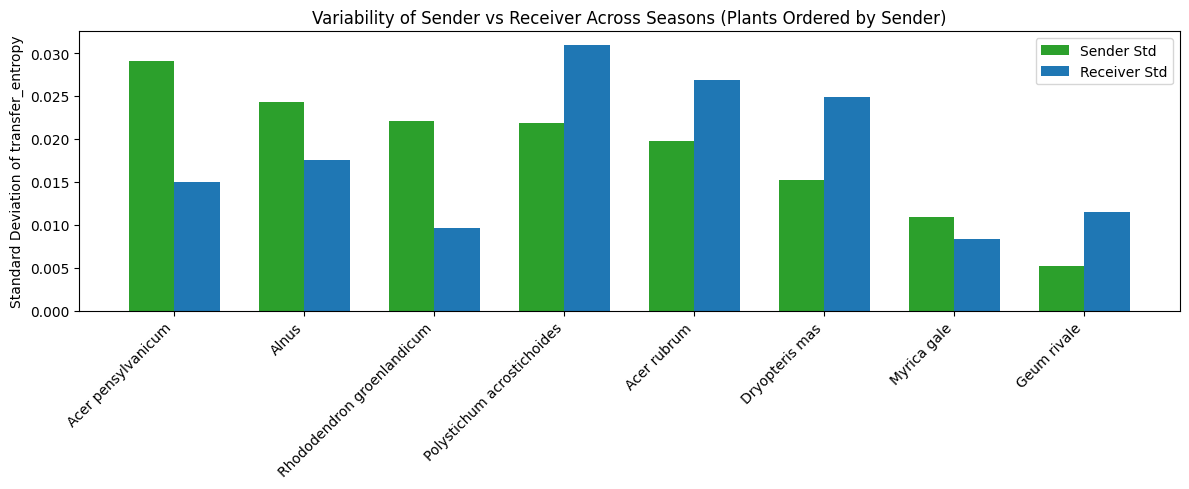

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure Season_mapped exists
if 'Season_mapped' not in df_all_seasons_combined.columns:
    df_all_seasons_combined['Season_mapped'] = df_all_seasons_combined['Season'].map(season_mapping)

# 1) Compute per-plant, per-season averages
sender_avg = (
    df_all_seasons_combined
    .groupby(['Plant1', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant1': 'Plant', metric: 'sender_avg'})
)

receiver_avg = (
    df_all_seasons_combined
    .groupby(['Plant2', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg'})
)

# 2) Compute standard deviation across seasons for each plant
sender_var = sender_avg.groupby('Plant')['sender_avg'].std().fillna(0)
receiver_var = receiver_avg.groupby('Plant')['receiver_avg'].std().fillna(0)

# 3) Order plants by descending sender variability
ordered_plants = sender_var.sort_values(ascending=False).index.tolist()

# 4) Prepare x positions
x = np.arange(len(ordered_plants))
width = 0.35

# 5) Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2,
       [sender_var[p] for p in ordered_plants],
       width, label='Sender Std', color='#2ca02c')
ax.bar(x + width/2,
       [receiver_var.get(p, 0) for p in ordered_plants],
       width, label='Receiver Std', color='#1f77b4')

# 6) Formatting
ax.set_xticks(x)
ax.set_xticklabels([plant_names.get(p, p) for p in ordered_plants], rotation=45, ha='right')
ax.set_ylabel(f'Standard Deviation of {metric}')
ax.set_title('Variability of Sender vs Receiver Across Seasons (Plants Ordered by Sender)')
ax.legend()
plt.tight_layout()
plt.show()


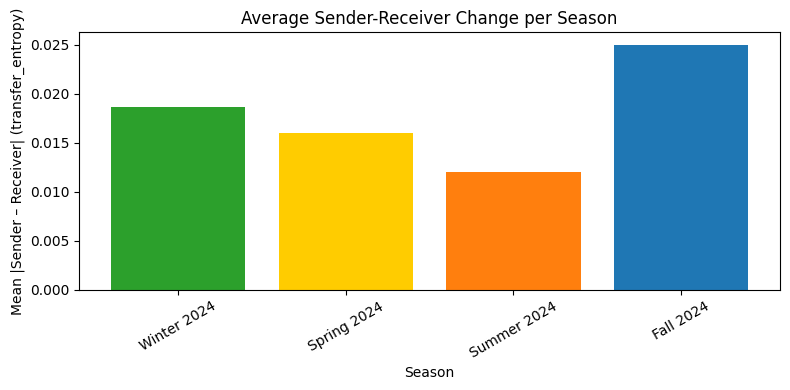

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Ensure Season_mapped exists
if 'Season_mapped' not in df_all_seasons_combined.columns:
    df_all_seasons_combined['Season_mapped'] = df_all_seasons_combined['Season'].map(season_mapping)

# 2) Compute average sender and receiver per Plant & Season
sender_avg = (
    df_all_seasons_combined
    .groupby(['Plant1', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant1': 'Plant', metric: 'sender_avg', 'Season_mapped': 'Season'})
)

receiver_avg = (
    df_all_seasons_combined
    .groupby(['Plant2', 'Season_mapped'])[metric]
    .mean()
    .reset_index()
    .rename(columns={'Plant2': 'Plant', metric: 'receiver_avg', 'Season_mapped': 'Season'})
)

# 3) Merge to get a DataFrame with sender and receiver averages
avg_df = pd.merge(sender_avg, receiver_avg, on=['Plant', 'Season'], how='inner')

# 4) Compute absolute difference per Plant & Season
avg_df['abs_diff'] = np.abs(avg_df['sender_avg'] - avg_df['receiver_avg'])

# 5) Compute mean absolute difference per Season
season_diff = avg_df.groupby('Season')['abs_diff'].mean()

# 6) Order seasons chronologically
season_index = {"Winter": 0, "Spring": 1, "Summer": 2, "Fall": 3}
season_order = sorted(
    season_diff.index,
    key=lambda nm: (int(nm.split()[1]), season_index[nm.split()[0]])
)

# 7) Define your color mapping
colors = ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"]  # spring, summer, fall, winter
# Align colors to season_order
# Assuming season_order is [Winter ..., Spring ..., Summer ..., Fall ...],
# we need to map each to the correct color:
color_map = {
    season: colors[idx]
    for idx, season in enumerate(season_order)
}

# 8) Plot bar chart
plt.figure(figsize=(8, 4))
values = [season_diff[s] for s in season_order]
bar_colors = [color_map[s] for s in season_order]
plt.bar(season_order, values, color=bar_colors)

plt.xlabel("Season")
plt.ylabel(f"Mean |Sender – Receiver| ({metric})")
plt.title("Average Sender-Receiver Change per Season")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [32]:
seasons

['Fall 2024', 'Spring 2024', 'Summer 2024', 'Winter 2025']

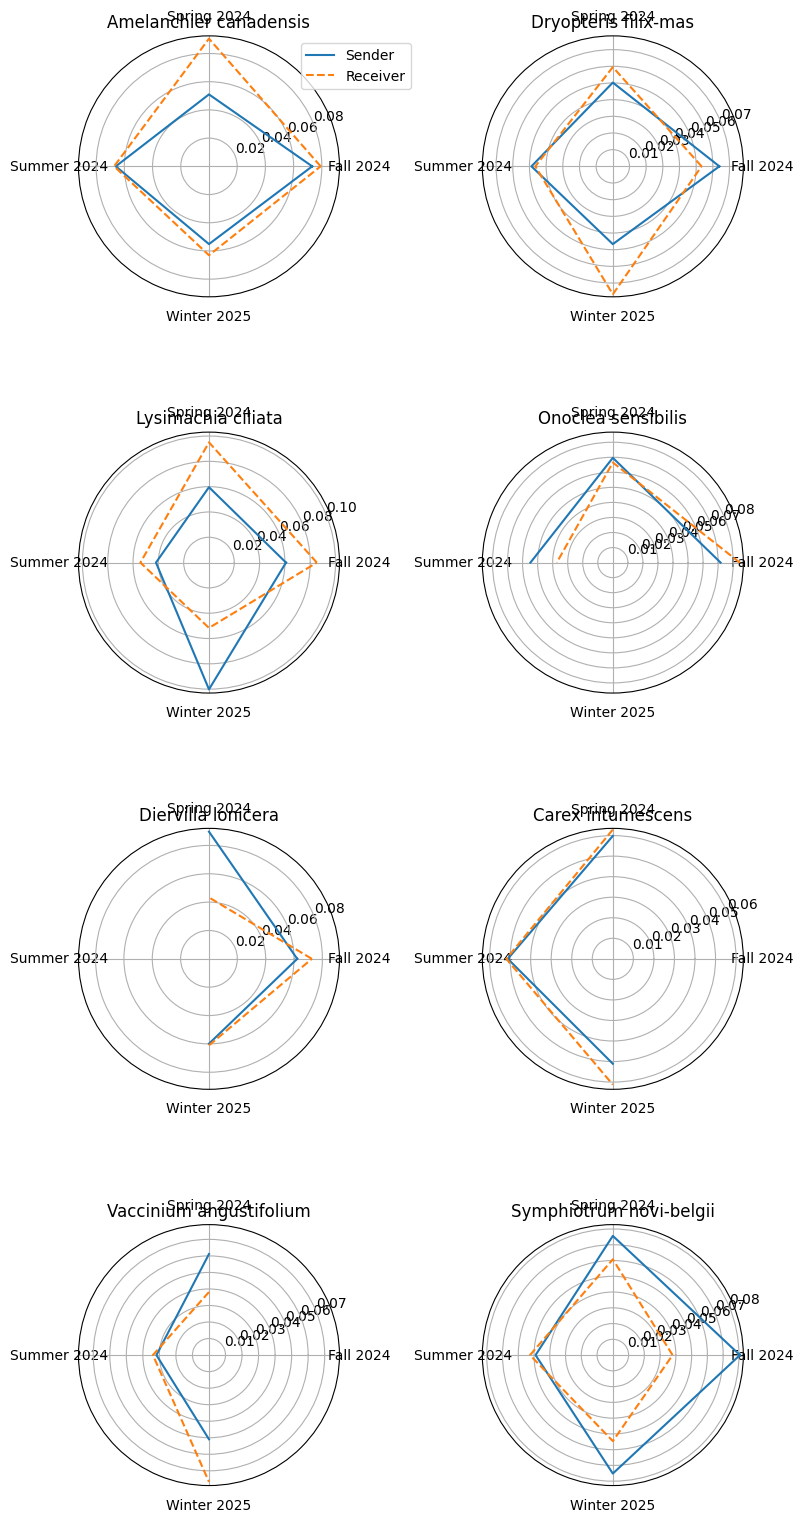

In [39]:
# Cell 4: Radar charts of seasonal profiles (Sender vs Receiver)
if 'df_all_seasons_combined' not in globals():
    print("Please define df_all_seasons_combined, season_mapping, plant_names, and metric before running this cell.")
else:
    import numpy as np

    # Compute seasonal averages
    sender_avg = (
        df_all_seasons_combined
        .groupby(['Plant1','Season_mapped'])[metric]
        .mean()
        .rename('sender')
        .reset_index()
    )
    receiver_avg = (
        df_all_seasons_combined
        .groupby(['Plant2','Season_mapped'])[metric]
        .mean()
        .rename('receiver')
        .reset_index()
    )

    # Merge into one DataFrame
    avg_df = pd.merge(
        sender_avg, receiver_avg,
        left_on=['Plant1','Season_mapped'],
        right_on=['Plant2','Season_mapped'],
        how='outer'  # outer so we don't lose plants or seasons entirely
    ).rename(columns={'Plant1':'Plant'}).drop(columns=['Plant2'])

    # Radar chart setup
    plants   = sorted(avg_df['Plant'].dropna().unique())
    seasons_ = sorted(df_all_seasons_combined['Season_mapped'].dropna().unique())
    N        = len(seasons_)
    # angles for each season axis
    angles   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles  += angles[:1]

    # figure with subplots in polar coordinates
    n_cols = 2
    n_rows = (len(plants) + 1) // 2
    fig    = plt.figure(figsize=(8, n_rows * 4))

    for idx, plant in enumerate(plants, start=1):
        ax = fig.add_subplot(n_rows, n_cols, idx, polar=True)

        # filter for this plant, then reindex so every season is present
        sub = avg_df[avg_df['Plant'] == plant].set_index('Season_mapped')
        sub = sub.reindex(seasons_, fill_value=np.nan)

        # extract values and close the loop
        sender_vals   = sub['sender'].tolist() + [sub['sender'].iloc[0]]
        receiver_vals = sub['receiver'].tolist() + [sub['receiver'].iloc[0]]

        # plot sender (solid) and receiver (dashed)
        ax.plot(angles, sender_vals,   linestyle='-',  label='Sender')
        ax.plot(angles, receiver_vals, linestyle='--', label='Receiver')

        # set the axis labels
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(seasons_)
        ax.set_title(plant_names.get(plant, plant))

        # only add legend on the first plot
        if idx == 1:
            ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    plt.tight_layout()
    plt.show()


# Sender across seasons

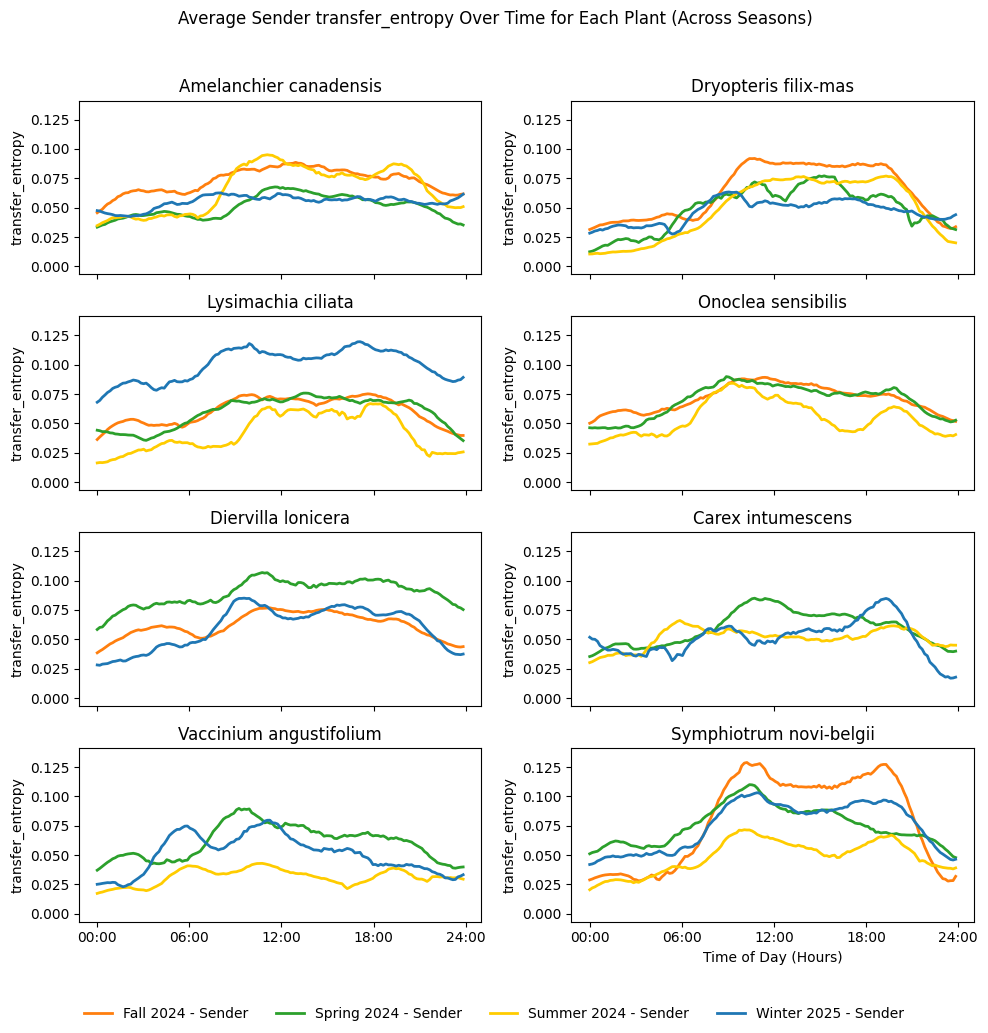

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
# Mapping of season series to human-readable names
season_mapping = seasons.copy()
# Ensure Season column is mapped correctly
if df_all_seasons_combined["Season"].iloc[0] in season_mapping:
    df_all_seasons_combined["Season"] = df_all_seasons_combined["Season"].map(season_mapping)

# Define season colors
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

# Smoothing parameters
window_length = 33  # Must be an odd number (adjust for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants and seasons
plants = sorted(df_all_seasons_combined["Plant1"].unique())
seasons = sorted(df_all_seasons_combined["Season"].dropna().unique())

# Compute global y-axis limits across all seasons
y_min, y_max = float("inf"), float("-inf")

for season in seasons:
    df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]

    df_senders = df_season.groupby(["Hour", "Plant1"], as_index=False)[metric].mean()
    df_receivers = df_season.groupby(["Hour", "Plant2"], as_index=False)[metric].mean()

    for df in [df_senders, df_receivers]:
        for plant in plants:
            subset = df[df[df.columns[1]] == plant].sort_values(by="Hour")
            if not subset.empty:  # Avoid empty subsets
                smoothed_entropy = (
                    savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
                    if len(subset) >= window_length else subset[metric].values
                )
                y_min = min(y_min, smoothed_entropy.min())
                y_max = max(y_max, smoothed_entropy.max())

# Add padding to y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

# Create subplots: 2 columns, automatic number of rows
n_cols = 2
n_rows = -(-len(plants) // n_cols)  # Equivalent to math.ceil(len(plants) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, n_rows * 2.5), sharex=True)
axes = axes.flatten()  # Convert to 1D array for easier indexing

for i, plant in enumerate(plants):
    ax = axes[i]

    for season in seasons:
        df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]

        df_senders = df_season.groupby(["Hour", "Plant1"], as_index=False)[metric].mean()
        df_receivers = df_season.groupby(["Hour", "Plant2"], as_index=False)[metric].mean()

        color = season_colors[season]

        # Process senders
        subset_senders = df_senders[df_senders["Plant1"] == plant].sort_values(by="Hour")
        if not subset_senders.empty:
            smoothed_sender = (
                savgol_filter(subset_senders[metric], window_length, polyorder, mode="nearest")
                if len(subset_senders) >= window_length else subset_senders[metric].values
            )
            ax.plot(subset_senders["Hour"], smoothed_sender, label=f"{season} - Sender", color=color, linestyle="-", linewidth=2)

        # Process receivers
        subset_receivers = df_receivers[df_receivers["Plant2"] == plant].sort_values(by="Hour")
        # if not subset_receivers.empty:
        #     smoothed_receiver = (
        #         savgol_filter(subset_receivers["Transfer Entropy"], window_length, polyorder, mode="nearest")
        #         if len(subset_receivers) >= window_length else subset_receivers["Transfer Entropy"].values
        #     )
        #     ax.plot(subset_receivers["Hour"], smoothed_receiver, label=f"{season} - Receiver", color=color, linestyle="--", linewidth=2)

    # Format subplot
    ax.set_ylabel(metric)
    ax.set_title(plant_names[plant])
    ax.set_ylim(y_min, y_max)

# Remove empty subplots if the number of plants is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Format x-axis
plt.xlabel("Time of Day (Hours)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])

# Add single legend below all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10, frameon=False)

# Adjust layout
plt.suptitle(f"Average Sender {metric} Over Time for Each Plant (Across Seasons)", y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Make space for legend
plt.show()


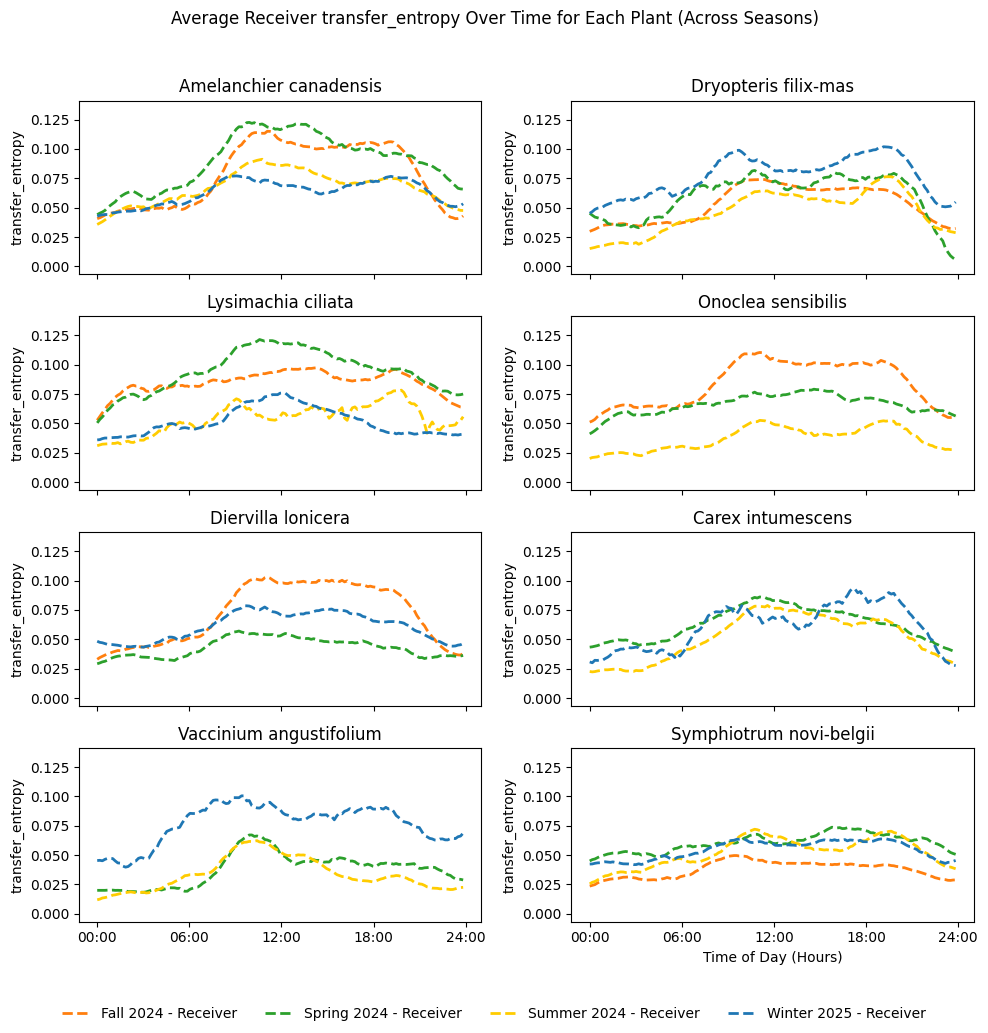

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

plant_names = {i: name for i, name in enumerate(plant_common_names.keys())}
# Mapping of season series to human-readable names
season_mapping = seasons.copy()
# Ensure Season column is mapped correctly
if df_all_seasons_combined["Season"].iloc[0] in season_mapping:
    df_all_seasons_combined["Season"] = df_all_seasons_combined["Season"].map(season_mapping)

# Define season colors
season_colors = {v: c for k, v, c in zip(season_mapping.keys(), season_mapping.values(), ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])}

# Smoothing parameters
window_length = 33  # Must be an odd number (adjust for more smoothing)
polyorder = 3  # Degree of polynomial (higher for more flexible fitting)

# Get unique plants and seasons
plants = sorted(df_all_seasons_combined["Plant1"].unique())
seasons = sorted(df_all_seasons_combined["Season"].dropna().unique())

# Compute global y-axis limits across all seasons
y_min, y_max = float("inf"), float("-inf")

for season in seasons:
    df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]

    df_senders = df_season.groupby(["Hour", "Plant1"], as_index=False)[metric].mean()
    df_receivers = df_season.groupby(["Hour", "Plant2"], as_index=False)[metric].mean()

    for df in [df_senders, df_receivers]:
        for plant in plants:
            subset = df[df[df.columns[1]] == plant].sort_values(by="Hour")
            if not subset.empty:  # Avoid empty subsets
                smoothed_entropy = (
                    savgol_filter(subset[metric], window_length, polyorder, mode="nearest")
                    if len(subset) >= window_length else subset[metric].values
                )
                y_min = min(y_min, smoothed_entropy.min())
                y_max = max(y_max, smoothed_entropy.max())

# Add padding to y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

# Create subplots: 2 columns, automatic number of rows
n_cols = 2
n_rows = -(-len(plants) // n_cols)  # Equivalent to math.ceil(len(plants) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, n_rows * 2.5), sharex=True)
axes = axes.flatten()  # Convert to 1D array for easier indexing

for i, plant in enumerate(plants):
    ax = axes[i]

    for season in seasons:
        df_season = df_all_seasons_combined[df_all_seasons_combined["Season"] == season]

        df_senders = df_season.groupby(["Hour", "Plant1"], as_index=False)[metric].mean()
        df_receivers = df_season.groupby(["Hour", "Plant2"], as_index=False)[metric].mean()

        color = season_colors[season]

        # Process senders
        # subset_senders = df_senders[df_senders["Plant1"] == plant].sort_values(by="Hour")
        # if not subset_senders.empty:
        #     smoothed_sender = (
        #         savgol_filter(subset_senders[metric], window_length, polyorder, mode="nearest")
        #         if len(subset_senders) >= window_length else subset_senders[metric].values
        #     )
        #     ax.plot(subset_senders["Hour"], smoothed_sender, label=f"{season} - Sender", color=color, linestyle="-", linewidth=2)

        # Process receivers
        subset_receivers = df_receivers[df_receivers["Plant2"] == plant].sort_values(by="Hour")
        if not subset_receivers.empty:
            smoothed_receiver = (
                savgol_filter(subset_receivers[metric], window_length, polyorder, mode="nearest")
                if len(subset_receivers) >= window_length else subset_receivers["Transfer Entropy"].values
            )
            ax.plot(subset_receivers["Hour"], smoothed_receiver, label=f"{season} - Receiver", color=color, linestyle="--", linewidth=2)

    # Format subplot
    ax.set_ylabel(metric)
    ax.set_title(plant_names[plant])
    ax.set_ylim(y_min, y_max)

# Remove empty subplots if the number of plants is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Format x-axis
plt.xlabel("Time of Day (Hours)")
plt.xticks(np.arange(0, 25, 6), labels=["00:00", "06:00", "12:00", "18:00", "24:00"])

# Add single legend below all subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10, frameon=False)

# Adjust layout
plt.suptitle(f"Average Receiver {metric} Over Time for Each Plant (Across Seasons)", y=1.02)
plt.tight_layout(rect=[0, 0.05, 1, 1])  # Make space for legend
plt.show()


## Graph (to do)

In [ ]:
# Sum transfer entropy per plant (as a sender)
df_sender = df_avg.groupby("Plant1")["Transfer Entropy"].sum().sort_values(ascending=False)

# Sum transfer entropy per plant (as a receiver)
df_receiver = df_avg.groupby("Plant2")["Transfer Entropy"].sum().sort_values(ascending=False)

print("Most influential plants (senders):\n", df_sender)
print("Most influenced plants (receivers):\n", df_receiver)


Most influential plants (senders):
 Plant1
4    89.806300
7    75.705200
3    69.712149
6    61.190010
5    59.885581
2    59.650150
0    51.052299
1    50.301026
Name: Transfer Entropy, dtype: float64
Most influenced plants (receivers):
 Plant2
2    95.118446
0    90.619902
3    66.618638
5    62.986605
7    60.823468
1    59.588469
4    43.363904
6    38.183281
Name: Transfer Entropy, dtype: float64


In [ ]:
# Sum transfer entropy per plant pair
df_pairs = df_avg.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().sort_values(ascending=False)

print("Strongest plant-to-plant interactions:\n", df_pairs.head(10))


Strongest plant-to-plant interactions:
 Plant1  Plant2
4       2         18.281732
        0         16.532861
7       2         16.024855
3       2         15.100745
7       0         14.169872
3       0         13.999335
4       3         13.992817
2       0         13.594779
4       7         13.488263
5       2         12.596934
Name: Transfer Entropy, dtype: float64


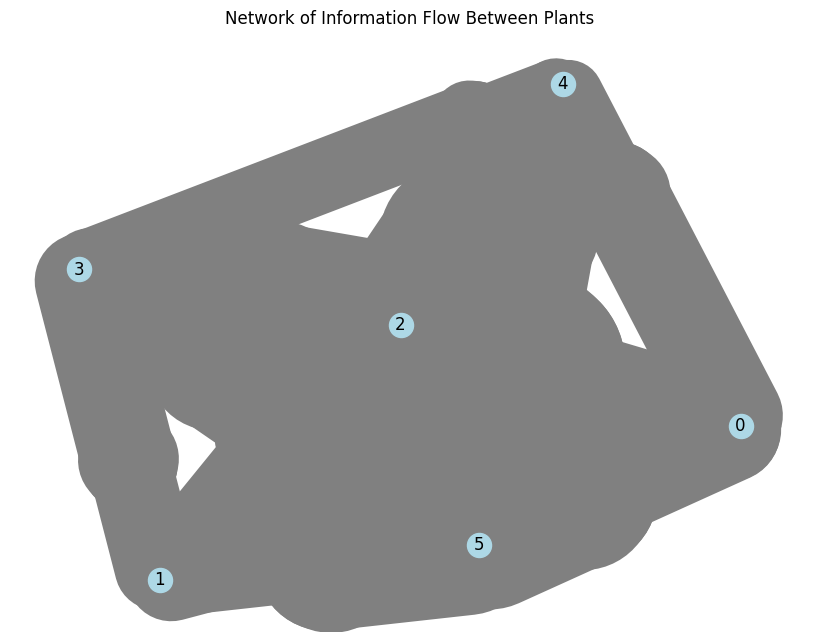

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add edges from df_results
for (plant1, plant2), entropy in df_results.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Draw network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)  # Layout for positioning nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", width=[d["weight"]*10 for (_, _, d) in G.edges(data=True)])
plt.title("Network of Information Flow Between Plants")
plt.show()


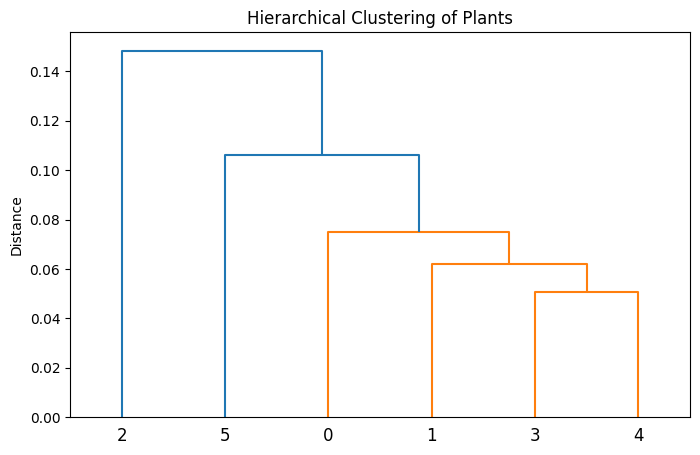

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Pivot table for clustering
df_cluster = df_results.pivot_table(index="Plant1", columns="Plant2", values="Transfer Entropy", fill_value=0)

# Perform clustering
linked = linkage(df_cluster, method="ward")

# Plot dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked, labels=df_cluster.index, orientation="top")
plt.title("Hierarchical Clustering of Plants")
plt.ylabel("Distance")
plt.show()


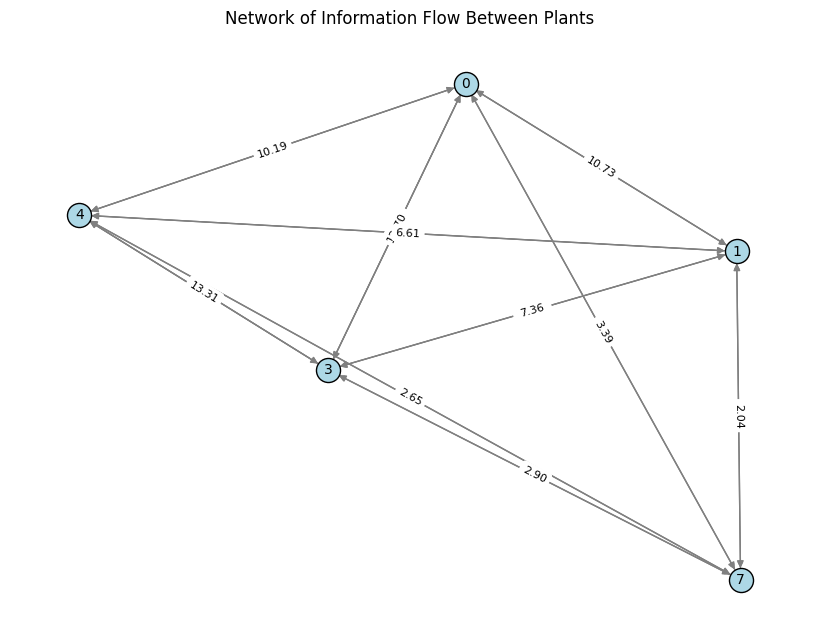

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges for transfer entropy (information flow)
for (plant1, plant2), entropy in df_results.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Draw the network
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # Layout for positioning nodes
edges = G.edges(data=True)

# Draw nodes
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", font_size=10, edgecolors="black")

# Draw edges with width proportional to entropy
nx.draw_networkx_edges(G, pos, width=[d["weight"] * 0.05 for (_, _, d) in edges], edge_color="gray")

# Add edge labels for transfer entropy values
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Network of Information Flow Between Plants")
plt.show()

# =============================
# Time-based Analysis: Evolution of Information Flow Over Epochs
# =============================




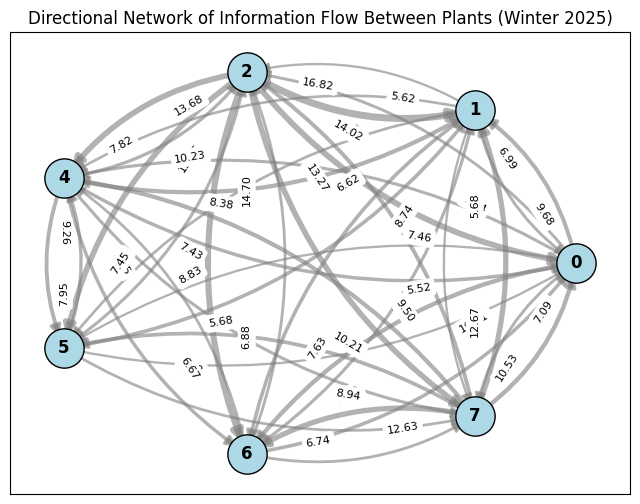

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Add edges for transfer entropy (information flow)
for (plant1, plant2), entropy in df_avg.groupby(["Plant1", "Plant2"])["Transfer Entropy"].sum().items():
    if entropy > 0:  # Only include meaningful interactions
        G.add_edge(plant1, plant2, weight=entropy)

# Adjust positions to avoid overlap
pos = nx.circular_layout(G)  # Circular layout reduces edge overlap

# Create figure
plt.figure(figsize=(8, 6))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color="lightblue", edgecolors="black", node_size=800)

# Draw directional edges with curved arrows to avoid overlap
edge_weights = [d["weight"] * 0.3 for (_, _, d) in G.edges(data=True)]
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=edge_weights, alpha=0.6,
                       edge_color="gray", arrows=True, arrowsize=15, connectionstyle="arc3,rad=0.2")

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold")

# Add edge labels (transfer entropy values)
edge_labels = {(i, j): f"{d['weight']:.2f}" for i, j, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.3)

plt.title("Directional Network of Information Flow Between Plants (Winter 2025)")
plt.show()
